<a href="https://colab.research.google.com/github/Fernandateireis/projecoes_cbae_ence/blob/main/cbo_cod.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Rodar os comandos operacionais direto no colab
Bibliotecas a serem utilizadas:

**transformers** → biblioteca da Hugging Face para usar modelos de linguagem como BERT, GPT, etc. É a base dos embeddings.

**torch** → PyTorch, o motor de deep learning por baixo dos panos. Os modelos de embedding rodam em cima dele.

**sentence-transformers** → simplifica o uso do transformers especificamente para gerar embeddings de frases e textos.

**pandas** → manipulação de tabelas/DataFrames. No R  equivalente ao dplyr ou  tidyr.

**numpy** → operações matemáticas com arrays e matrizes. Usado nos cálculos de similaridade.

**scikit-learn** → machine learning geral. Usamos só a função cosine_similarity dele.

**openpyxl** → lê e escreve arquivos .xlsx. O pandas depende dele para abrir Excel.



In [ ]:
!pip install sentence-transformers pandas numpy scikit-learn openpyxl pyarrow -q

import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

**Abrir as bases que foram salvas em parquet**

O from google.colab import files as colab_files	evita conflito com qualquer variável files que possa ter sido criada antes na sessão

O io.BytesIO(conteudo)	Lê o parquet direto da memória sem precisar salvar em disco

In [ ]:
from google.colab import files as colab_files
import pandas as pd

print("Selecione os arquivos base_cbo.parquet e base_cod.parquet...")
uploaded = colab_files.upload()

for nome_arq, conteudo in uploaded.items():
    import io
    if 'cbo' in nome_arq.lower():
        cbo_wide = pd.read_parquet(io.BytesIO(conteudo))
        print(f"✅ CBO: {cbo_wide.shape}")
        print("Colunas:", cbo_wide.columns.tolist()[:5])
    elif 'cod' in nome_arq.lower():
        cod_wide = pd.read_parquet(io.BytesIO(conteudo))
        print(f"✅ COD: {cod_wide.shape}")
        print("Colunas:", cod_wide.columns.tolist()[:5])

Selecione os arquivos base_cbo.parquet e base_cod.parquet...


Saving base_cbo.parquet to base_cbo.parquet
Saving base_cod.parquet to base_cod.parquet
✅ CBO: (627, 206)
Colunas: ['cod_familia', 'titulo_familia', 'ocupacao_1', 'ocupacao_2', 'ocupacao_3']
✅ COD: (434, 610)
Colunas: ['cod_familia', 'titulo_familia', 'cod_descritor_1', 'cod_descritor_2', 'cod_descritor_3']


Rodando escalonado e com travas grandes grupos 2 e 3

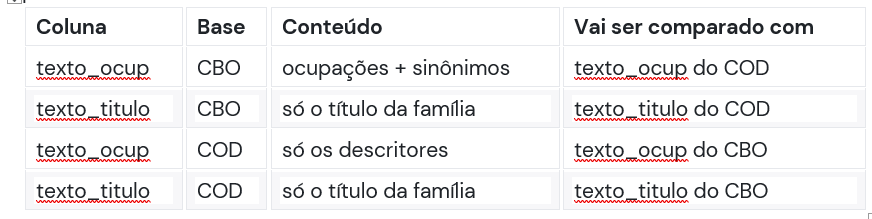

In [ ]:
cols_ocupacao_cbo = [c for c in cbo_wide.columns if c.startswith('ocupacao_')]
cols_sinonimo_cbo = [c for c in cbo_wide.columns if c.startswith('sinomino')]
cols_descritor_cod = [c for c in cod_wide.columns if c.startswith('cod_descritor_')]

# --- CBO: texto ocupacional (ocupações + sinônimos, SEM título) ---
cbo_wide['texto_ocup'] = (
    cbo_wide[cols_ocupacao_cbo].apply(
        lambda row: ' '.join(row.dropna().astype(str).str.strip()), axis=1
    )
    + ' '
    + cbo_wide[cols_sinonimo_cbo].apply(
        lambda row: ' '.join(row.dropna().astype(str).str.strip()), axis=1
    )
).str.lower().str.strip()

# --- CBO: texto de título (só titulo_familia) ---
cbo_wide['texto_titulo'] = cbo_wide['titulo_familia'].fillna('').astype(str).str.lower().str.strip()

# --- COD: texto ocupacional (só descritores, SEM título) ---
cod_wide['texto_ocup'] = (
    cod_wide[cols_descritor_cod].apply(
        lambda row: ' '.join(row.dropna().astype(str).str.strip()), axis=1
    )
).str.lower().str.strip()

# --- COD: texto de título (só titulo_familia) ---
cod_wide['texto_titulo'] = cod_wide['titulo_familia'].fillna('').astype(str).str.lower().str.strip()

print("Exemplo CBO texto_ocup:", cbo_wide['texto_ocup'].iloc[0][:200])
print("\nExemplo COD texto_ocup:", cod_wide['texto_ocup'].iloc[0][:200])
print("\nExemplo CBO texto_titulo:", cbo_wide['texto_titulo'].iloc[0])
print("Exemplo COD texto_titulo:", cod_wide['texto_titulo'].iloc[0])

Exemplo CBO texto_ocup: oficial general da aeronáutica oficial general do exército oficial general da marinha brigadeiro major-brigadeiro marechal-do-ar tenente-brigadeiro general-de-brigada general-de-divisão general-de-exé

Exemplo COD texto_ocup: almirante almirante de esquadra aluno centro de preparação oficiais reserva aspirante a oficial da aeronáutica aspirante a oficial da marinha aspirante a oficial do exército brigadeiro cadete da aeron

Exemplo CBO texto_titulo: oficiais generais das forças armadas
Exemplo COD texto_titulo: oficiais das forças armadas


In [ ]:
# ============================================================
# Filtrar válidos e extrair nível
# ============================================================
cbo_valid = cbo_wide[cbo_wide['texto_ocup'].str.len() > 5].copy().reset_index(drop=True)
cod_valid = cod_wide[cod_wide['texto_ocup'].str.len() > 5].copy().reset_index(drop=True)

cbo_valid['nivel_cbo'] = cbo_valid['cod_familia'].astype(str).str.zfill(4).str[0]
cod_valid['nivel_cod'] = cod_valid['cod_familia'].astype(str).str.zfill(4).str[0]

print("CBO válidos:", len(cbo_valid))
print("COD válidos:", len(cod_valid))
print("Níveis CBO:", sorted(cbo_valid['nivel_cbo'].unique()))
print("Níveis COD:", sorted(cod_valid['nivel_cod'].unique()))

CBO válidos: 625
COD válidos: 434
Níveis CBO: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Níveis COD: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


**Geramos 4 embeddings**

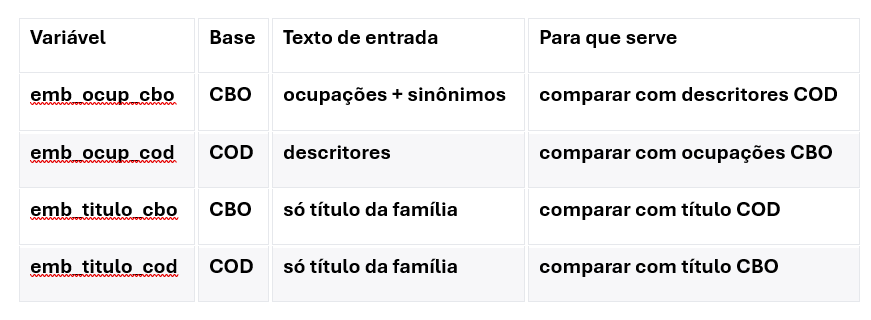


In [ ]:
# ============================================================
# Embeddings (4 vetores separados)
# ============================================================
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

print("Gerando embeddings ocupacionais CBO...")
emb_ocup_cbo = model.encode(cbo_valid['texto_ocup'].tolist(), show_progress_bar=True)

print("Gerando embeddings ocupacionais COD...")
emb_ocup_cod = model.encode(cod_valid['texto_ocup'].tolist(), show_progress_bar=True)

print("Gerando embeddings de título CBO...")
emb_titulo_cbo = model.encode(cbo_valid['texto_titulo'].tolist(), show_progress_bar=True)

print("Gerando embeddings de título COD...")
emb_titulo_cod = model.encode(cod_valid['texto_titulo'].tolist(), show_progress_bar=True)

print("\nShapes:")
print("  emb_ocup_cbo :", emb_ocup_cbo.shape)
print("  emb_ocup_cod :", emb_ocup_cod.shape)
print("  emb_titulo_cbo:", emb_titulo_cbo.shape)
print("  emb_titulo_cod:", emb_titulo_cod.shape)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

Gerando embeddings de título CBO...


Batches:   0%|          | 0/20 [00:00<?, ?it/s]

Gerando embeddings de título COD...


Batches:   0%|          | 0/14 [00:00<?, ?it/s]


Shapes:
  emb_ocup_cbo : (625, 384)
  emb_ocup_cod : (434, 384)
  emb_titulo_cbo: (625, 384)
  emb_titulo_cod: (434, 384)


Vou primeiro rodar o modelo com travas entre os grandes grupos 2 (nível superior) e 3 (nível médio)

In [ ]:
# ============================================================
# Matrizes de similaridade + escalonamento via mínimo com travas
# ============================================================

# Score A: ocupações/sinônimos CBO  ←→  descritores COD
sim_ocup  = cosine_similarity(emb_ocup_cbo,   emb_ocup_cod)

# Score B: título CBO  ←→  título COD
sim_titulo = cosine_similarity(emb_titulo_cbo, emb_titulo_cod)

# Score final: mínimo dos dois (só passa se ambos forem bons)
sim_final = np.minimum(sim_ocup, sim_titulo)

print("sim_ocup  :", sim_ocup.shape)
print("sim_titulo:", sim_titulo.shape)
print("sim_final :", sim_final.shape)

# Regra estrutural: bloquear pares nível 2 vs 3
nivel_cbo_arr = cbo_valid['nivel_cbo'].values.reshape(-1, 1)
nivel_cod_arr = cod_valid['nivel_cod'].values.reshape(1, -1)

par_bloqueado = (
    ((nivel_cbo_arr == '2') & (nivel_cod_arr == '3')) |
    ((nivel_cbo_arr == '3') & (nivel_cod_arr == '2'))
)

sim_final_filtrada = sim_final.copy()
sim_final_filtrada[par_bloqueado] = -1.0

print("Pares bloqueados (2 vs 3):", par_bloqueado.sum())
print("Pares permitidos:", (~par_bloqueado).sum())

sim_ocup  : (625, 434)
sim_titulo: (625, 434)
sim_final : (625, 434)
Pares bloqueados (2 vs 3): 20684
Pares permitidos: 250566


In [ ]:
# ============================================================
# Top 1 (COM bloqueio 2↔3)
# ============================================================
matches_top1 = []

for i in range(len(cbo_valid)):
    sims = sim_final_filtrada[i]
    j    = np.argmax(sims)
    matches_top1.append({
        'cod_familia_cbo'   : cbo_valid.iloc[i]['cod_familia'],
        'titulo_familia_cbo': cbo_valid.iloc[i]['titulo_familia'],
        'nivel_cbo'         : cbo_valid.iloc[i]['nivel_cbo'],
        'cod_familia_cod'   : cod_valid.iloc[j]['cod_familia'],
        'titulo_familia_cod': cod_valid.iloc[j]['titulo_familia'],
        'nivel_cod'         : cod_valid.iloc[j]['nivel_cod'],
        'sim_ocup'          : round(float(sim_ocup[i, j]),   4),
        'sim_titulo'        : round(float(sim_titulo[i, j]), 4),
        'sim_final'         : round(float(sims[j]),          4)
    })

base_match_top1 = pd.DataFrame(matches_top1)

# Filtro de confiança
base_match_top1_filtrado = base_match_top1[
    base_match_top1['sim_final'] >= 0.5
].reset_index(drop=True)

# Checa pares 2↔3 (com bloqueio ativo, deve ser 0)
erros = base_match_top1_filtrado[
    ((base_match_top1_filtrado['nivel_cbo'] == '2') & (base_match_top1_filtrado['nivel_cod'] == '3')) |
    ((base_match_top1_filtrado['nivel_cbo'] == '3') & (base_match_top1_filtrado['nivel_cod'] == '2'))
]

print("Total CBO:", len(cbo_valid))
print("Top 1 com sim_final >= 0.5:", len(base_match_top1_filtrado))
print("Pares 2↔3 (com bloqueio, ideal 0):", len(erros))

display(base_match_top1_filtrado[[
    'cod_familia_cbo', 'titulo_familia_cbo', 'nivel_cbo',
    'cod_familia_cod', 'titulo_familia_cod', 'nivel_cod',
    'sim_ocup', 'sim_titulo', 'sim_final'
]].head(10))



Total CBO: 625
Top 1 com sim_final >= 0.5: 604
Pares 2↔3 (com bloqueio, ideal 0): 0


,cod_familia_cbo,titulo_familia_cbo,nivel_cbo,cod_familia_cod,titulo_familia_cod,nivel_cod,sim_ocup,sim_titulo,sim_final
0,0101,Oficiais generais das forças armadas,0,0110,Oficiais das forças armadas,0,0.7820,0.9495,0.7820
1,0102,Oficiais das forças armadas,0,0110,Oficiais das forças armadas,0,0.9076,1.0000,0.9076
2,0103,Praças das forças armadas,0,0110,Oficiais das forças armadas,0,0.8101,0.8913,0.8101
3,0201,Oficiais superiores da polícia militar,0,0412,Graduados e praças da polícia militar,0,0.8170,0.8612,0.8170
4,0202,Capitães da polícia militar,0,0412,Graduados e praças da polícia militar,0,0.7389,0.8368,0.7389
5,0203,Tenentes da polícia militar,0,0412,Graduados e praças da polícia militar,0,0.8254,0.8701,0.8254
6,0211,Subtenentes e sargentos da policia militar,0,0412,Graduados e praças da polícia militar,0,0.8456,0.8836,0.8456
7,0212,Cabos e soldados da polícia militar,0,0412,Graduados e praças da polícia militar,0,0.7999,0.7886,0.7886
8,0301,Oficiais superiores do corpo de bombeiros militar,0,0511,Oficiais de bombeiro militar,0,0.8609,0.9611,0.8609
9,0302,Oficiais intermediários do corpo de bombeiros ...,0,0511,Oficiais de bombeiro militar,0,0.8290,0.9553,0.8290


In [ ]:
# ============================================================
# Top 1 com sim_final >= 0.7
# ============================================================
base_match_top1_07 = base_match_top1[
    base_match_top1['sim_final'] >= 0.5
].reset_index(drop=True)

print("Top 1 >= 0.5:", len(base_match_top1_07), "de", len(cbo_valid), "CBO")

display(base_match_top1_07[[
    'cod_familia_cbo', 'titulo_familia_cbo', 'nivel_cbo',
    'cod_familia_cod', 'titulo_familia_cod', 'nivel_cod',
    'sim_ocup', 'sim_titulo', 'sim_final'
]].head(10))


Top 1 >= 0.5: 604 de 625 CBO


,cod_familia_cbo,titulo_familia_cbo,nivel_cbo,cod_familia_cod,titulo_familia_cod,nivel_cod,sim_ocup,sim_titulo,sim_final
0,0101,Oficiais generais das forças armadas,0,0110,Oficiais das forças armadas,0,0.7820,0.9495,0.7820
1,0102,Oficiais das forças armadas,0,0110,Oficiais das forças armadas,0,0.9076,1.0000,0.9076
2,0103,Praças das forças armadas,0,0110,Oficiais das forças armadas,0,0.8101,0.8913,0.8101
3,0201,Oficiais superiores da polícia militar,0,0412,Graduados e praças da polícia militar,0,0.8170,0.8612,0.8170
4,0202,Capitães da polícia militar,0,0412,Graduados e praças da polícia militar,0,0.7389,0.8368,0.7389
5,0203,Tenentes da polícia militar,0,0412,Graduados e praças da polícia militar,0,0.8254,0.8701,0.8254
6,0211,Subtenentes e sargentos da policia militar,0,0412,Graduados e praças da polícia militar,0,0.8456,0.8836,0.8456
7,0212,Cabos e soldados da polícia militar,0,0412,Graduados e praças da polícia militar,0,0.7999,0.7886,0.7886
8,0301,Oficiais superiores do corpo de bombeiros militar,0,0511,Oficiais de bombeiro militar,0,0.8609,0.9611,0.8609
9,0302,Oficiais intermediários do corpo de bombeiros ...,0,0511,Oficiais de bombeiro militar,0,0.8290,0.9553,0.8290


In [ ]:
# ============================================================
# CÉLULA 8 — Top 3
# ============================================================
top3_matches = []

for i in range(len(cbo_valid)):
    sims     = sim_final_filtrada[i]
    top3_idx = np.argsort(sims)[-3:][::-1]

    for rank, j in enumerate(top3_idx, start=1):
        top3_matches.append({
            'cod_familia_cbo'   : cbo_valid.iloc[i]['cod_familia'],
            'titulo_familia_cbo': cbo_valid.iloc[i]['titulo_familia'],
            'nivel_cbo'         : cbo_valid.iloc[i]['nivel_cbo'],
            'cod_familia_cod'   : cod_valid.iloc[j]['cod_familia'],
            'titulo_familia_cod': cod_valid.iloc[j]['titulo_familia'],
            'nivel_cod'         : cod_valid.iloc[j]['nivel_cod'],
            'rank'              : rank,
            'sim_ocup'          : round(float(sim_ocup[i, j]),   4),
            'sim_titulo'        : round(float(sim_titulo[i, j]), 4),
            'sim_final'         : round(float(sims[j]),          4)
        })

base_match_top3 = pd.DataFrame(top3_matches)

base_match_top3_filtrado = base_match_top3[
    base_match_top3['sim_final'] >= 0.5
].reset_index(drop=True)

erros_top3 = base_match_top3_filtrado[
    ((base_match_top3_filtrado['nivel_cbo'] == '2') & (base_match_top3_filtrado['nivel_cod'] == '3')) |
    ((base_match_top3_filtrado['nivel_cbo'] == '3') & (base_match_top3_filtrado['nivel_cod'] == '2'))
]

print("Total linhas Top 3 (sem filtro):", len(base_match_top3))
print("Top 3 com sim_final >= 0.5:", len(base_match_top3_filtrado))
print("Pares 2↔3 (ideal 0):", len(erros_top3))
display(base_match_top3_filtrado.head(15))

Total linhas Top 3 (sem filtro): 1875
Top 3 com sim_final >= 0.5: 1710
Pares 2↔3 (ideal 0): 0


,cod_familia_cbo,titulo_familia_cbo,nivel_cbo,cod_familia_cod,titulo_familia_cod,nivel_cod,rank,sim_ocup,sim_titulo,sim_final
0,0101,Oficiais generais das forças armadas,0,0110,Oficiais das forças armadas,0,1,0.7820,0.9495,0.7820
1,0101,Oficiais generais das forças armadas,0,0511,Oficiais de bombeiro militar,0,2,0.6659,0.7491,0.6659
2,0101,Oficiais generais das forças armadas,0,0411,Oficiais de polícia militar,0,3,0.6414,0.8441,0.6414
3,0102,Oficiais das forças armadas,0,0110,Oficiais das forças armadas,0,1,0.9076,1.0000,0.9076
4,0102,Oficiais das forças armadas,0,0210,Graduados e praças das forças armadas,0,2,0.7719,0.8319,0.7719
5,0102,Oficiais das forças armadas,0,3152,"Capitães, oficiais de coberta e práticos",3,3,0.6951,0.7629,0.6951
6,0103,Praças das forças armadas,0,0110,Oficiais das forças armadas,0,1,0.8101,0.8913,0.8101
7,0103,Praças das forças armadas,0,0210,Graduados e praças das forças armadas,0,2,0.8080,0.8292,0.8080
8,0103,Praças das forças armadas,0,3152,"Capitães, oficiais de coberta e práticos",3,3,0.6447,0.6410,0.6410
9,0201,Oficiais superiores da polícia militar,0,0412,Graduados e praças da polícia militar,0,1,0.8170,0.8612,0.8170


In [ ]:
# ============================================================
# CÉLULA 9 — Exportar
# ============================================================
base_match_top1_filtrado[[
    'cod_familia_cbo', 'titulo_familia_cbo', 'nivel_cbo',
    'cod_familia_cod', 'titulo_familia_cod', 'nivel_cod',
    'sim_ocup', 'sim_titulo', 'sim_final'
]].to_excel('match_top1_escalonado.xlsx', index=False)

base_match_top3_filtrado[[
    'cod_familia_cbo', 'titulo_familia_cbo', 'nivel_cbo',
    'cod_familia_cod', 'titulo_familia_cod', 'nivel_cod',
    'rank', 'sim_ocup', 'sim_titulo', 'sim_final'
]].to_excel('match_top3_escalonado.xlsx', index=False)

colab_files.download('match_top1_escalonado.xlsx')
colab_files.download('match_top3_escalonado.xlsx')

print("✅ Exportado com sucesso!")
print(f"Top 1: {len(base_match_top1_filtrado)} linhas")
print(f"Top 3: {len(base_match_top3_filtrado)} linhas")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Exportado com sucesso!
Top 1: 604 linhas
Top 3: 1710 linhas


**Rodando escalonado e sem travas grandes grupos 2 e 3**


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Score A: ocupações/sinônimos CBO  ←→  descritores COD
sim_ocup = cosine_similarity(emb_ocup_cbo, emb_ocup_cod)

# Score B: título CBO  ←→  título COD
sim_titulo = cosine_similarity(emb_titulo_cbo, emb_titulo_cod)

# Score final: mínimo dos dois
sim_final = np.minimum(sim_ocup, sim_titulo)

print("sim_ocup  :", sim_ocup.shape)
print("sim_titulo:", sim_titulo.shape)
print("sim_final :", sim_final.shape)

# SEM QUALQUER REGRA DE NÍVEL
sim_final_filtrada = sim_final.copy()

sim_ocup  : (625, 434)
sim_titulo: (625, 434)
sim_final : (625, 434)


In [ ]:
# ============================================================
# Top 1 — escalonado, SEM bloqueio de nível
# ============================================================
matches_top1 = []

for i in range(len(cbo_valid)):
    sims = sim_final_filtrada[i]   # matriz já sem bloqueio
    j    = np.argmax(sims)        # melhor COD para esse CBO

    matches_top1.append({
        'cod_familia_cbo'   : cbo_valid.iloc[i]['cod_familia'],
        'titulo_familia_cbo': cbo_valid.iloc[i]['titulo_familia'],
        'nivel_cbo'         : cbo_valid.iloc[i]['nivel_cbo'],

        'cod_familia_cod'   : cod_valid.iloc[j]['cod_familia'],
        'titulo_familia_cod': cod_valid.iloc[j]['titulo_familia'],
        'nivel_cod'         : cod_valid.iloc[j]['nivel_cod'],

        'sim_ocup'          : round(float(sim_ocup[i, j]),   4),
        'sim_titulo'        : round(float(sim_titulo[i, j]), 4),
        'sim_final'         : round(float(sims[j]),          4)
    })

base_match_top1 = pd.DataFrame(matches_top1)

# Filtro de confiança em cima do score final
base_match_top1_filtrado = base_match_top1[
    base_match_top1['sim_final'] >= 0.001
].reset_index(drop=True)

# Observação: qualquer par com níveis diferentes (só para análise)
pares_nivel_diferente_top1 = base_match_top1_filtrado[
    base_match_top1_filtrado['nivel_cbo'] != base_match_top1_filtrado['nivel_cod']
]

print("Total CBO:", len(cbo_valid))
print("Top 1 com sim_final >= 0.001:", len(base_match_top1_filtrado))
print("Pares com níveis diferentes (sem bloqueio):", len(pares_nivel_diferente_top1))

# Para visualizar todas as colunas no Colab:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

display(base_match_top1_filtrado[[
    'cod_familia_cbo', 'titulo_familia_cbo', 'nivel_cbo',
    'cod_familia_cod', 'titulo_familia_cod', 'nivel_cod',
    'sim_ocup', 'sim_titulo', 'sim_final'
]].head(10))

Total CBO: 625
Top 1 com sim_final >= 0.001: 625
Pares com níveis diferentes (sem bloqueio): 269


,cod_familia_cbo,titulo_familia_cbo,nivel_cbo,cod_familia_cod,titulo_familia_cod,nivel_cod,sim_ocup,sim_titulo,sim_final
0,0101,Oficiais generais das forças armadas,0,0110,Oficiais das forças armadas,0,0.7820,0.9495,0.7820
1,0102,Oficiais das forças armadas,0,0110,Oficiais das forças armadas,0,0.9076,1.0000,0.9076
2,0103,Praças das forças armadas,0,0110,Oficiais das forças armadas,0,0.8101,0.8913,0.8101
3,0201,Oficiais superiores da polícia militar,0,0412,Graduados e praças da polícia militar,0,0.8170,0.8612,0.8170
4,0202,Capitães da polícia militar,0,0412,Graduados e praças da polícia militar,0,0.7389,0.8368,0.7389
5,0203,Tenentes da polícia militar,0,0412,Graduados e praças da polícia militar,0,0.8254,0.8701,0.8254
6,0211,Subtenentes e sargentos da policia militar,0,0412,Graduados e praças da polícia militar,0,0.8456,0.8836,0.8456
7,0212,Cabos e soldados da polícia militar,0,0412,Graduados e praças da polícia militar,0,0.7999,0.7886,0.7886
8,0301,Oficiais superiores do corpo de bombeiros militar,0,0511,Oficiais de bombeiro militar,0,0.8609,0.9611,0.8609
9,0302,Oficiais intermediários do corpo de bombeiros ...,0,0511,Oficiais de bombeiro militar,0,0.8290,0.9553,0.8290


In [ ]:
# ============================================================
# Top 3 — escalonado, SEM bloqueio de nível
# ============================================================
top3_matches = []

for i in range(len(cbo_valid)):
    sims     = sim_final_filtrada[i]
    top3_idx = np.argsort(sims)[-3:][::-1]

    for rank, j in enumerate(top3_idx, start=1):
        top3_matches.append({
            'cod_familia_cbo'   : cbo_valid.iloc[i]['cod_familia'],
            'titulo_familia_cbo': cbo_valid.iloc[i]['titulo_familia'],
            'nivel_cbo'         : cbo_valid.iloc[i]['nivel_cbo'],

            'cod_familia_cod'   : cod_valid.iloc[j]['cod_familia'],
            'titulo_familia_cod': cod_valid.iloc[j]['titulo_familia'],
            'nivel_cod'         : cod_valid.iloc[j]['nivel_cod'],

            'rank'              : rank,
            'sim_ocup'          : round(float(sim_ocup[i, j]),   4),
            'sim_titulo'        : round(float(sim_titulo[i, j]), 4),
            'sim_final'         : round(float(sims[j]),          4)
        })

base_match_top3 = pd.DataFrame(top3_matches)

base_match_top3_filtrado = base_match_top3[
    base_match_top3['sim_final'] >= 0.5
].reset_index(drop=True)

pares_nivel_diferente_top3 = base_match_top3_filtrado[
    base_match_top3_filtrado['nivel_cbo'] != base_match_top3_filtrado['nivel_cod']
]

print("Total linhas Top 3 (sem filtro):", len(base_match_top3))
print("Top 3 com sim_final >= 0.5:", len(base_match_top3_filtrado))
print("Pares com níveis diferentes (sem bloqueio):", len(pares_nivel_diferente_top3))

display(base_match_top3_filtrado[[
    'cod_familia_cbo', 'titulo_familia_cbo', 'nivel_cbo',
    'cod_familia_cod', 'titulo_familia_cod', 'nivel_cod',
    'rank', 'sim_ocup', 'sim_titulo', 'sim_final'
]].head(15))

Total linhas Top 3 (sem filtro): 1875
Top 3 com sim_final >= 0.5: 1744
Pares com níveis diferentes (sem bloqueio): 927


,cod_familia_cbo,titulo_familia_cbo,nivel_cbo,cod_familia_cod,titulo_familia_cod,nivel_cod,rank,sim_ocup,sim_titulo,sim_final
0,0101,Oficiais generais das forças armadas,0,0110,Oficiais das forças armadas,0,1,0.7820,0.9495,0.7820
1,0101,Oficiais generais das forças armadas,0,0511,Oficiais de bombeiro militar,0,2,0.6659,0.7491,0.6659
2,0101,Oficiais generais das forças armadas,0,0411,Oficiais de polícia militar,0,3,0.6414,0.8441,0.6414
3,0102,Oficiais das forças armadas,0,0110,Oficiais das forças armadas,0,1,0.9076,1.0000,0.9076
4,0102,Oficiais das forças armadas,0,0210,Graduados e praças das forças armadas,0,2,0.7719,0.8319,0.7719
5,0102,Oficiais das forças armadas,0,3152,"Capitães, oficiais de coberta e práticos",3,3,0.6951,0.7629,0.6951
6,0103,Praças das forças armadas,0,0110,Oficiais das forças armadas,0,1,0.8101,0.8913,0.8101
7,0103,Praças das forças armadas,0,0210,Graduados e praças das forças armadas,0,2,0.8080,0.8292,0.8080
8,0103,Praças das forças armadas,0,3152,"Capitães, oficiais de coberta e práticos",3,3,0.6447,0.6410,0.6410
9,0201,Oficiais superiores da polícia militar,0,0412,Graduados e praças da polícia militar,0,1,0.8170,0.8612,0.8170


In [ ]:
from google.colab import files as colab_files

base_match_top1_filtrado[[
    'cod_familia_cbo', 'titulo_familia_cbo', 'nivel_cbo',
    'cod_familia_cod', 'titulo_familia_cod', 'nivel_cod',
    'sim_ocup', 'sim_titulo', 'sim_final'
]].to_excel('match_top1_escalonado_sem_bloqueio.xlsx', index=False)

base_match_top3_filtrado[[
    'cod_familia_cbo', 'titulo_familia_cbo', 'nivel_cbo',
    'cod_familia_cod', 'titulo_familia_cod', 'nivel_cod',
    'rank', 'sim_ocup', 'sim_titulo', 'sim_final'
]].to_excel('match_top3_escalonado_sem_bloqueio.xlsx', index=False)

colab_files.download('match_top1_escalonado_sem_bloqueio.xlsx')
colab_files.download('match_top3_escalonado_sem_bloqueio.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Só família, sem trava e sem limite

In [ ]:
!pip install sentence-transformers -q

from sentence_transformers import SentenceTransformer
import numpy as np

# Modelo local (pode ser o mesmo que você já usava)
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

print("Gerando embeddings CBO (titulo_familia)...")
emb_titulo_cbo = model.encode(
    cbo_valid['titulo_familia'].tolist(),
    convert_to_numpy=True,
    show_progress_bar=True
)

print("Gerando embeddings COD (titulo_familia)...")
emb_titulo_cod = model.encode(
    cod_valid['titulo_familia'].tolist(),
    convert_to_numpy=True,
    show_progress_bar=True
)

print("Shapes:")
print("emb_titulo_cbo:", emb_titulo_cbo.shape)
print("emb_titulo_cod:", emb_titulo_cod.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Gerando embeddings CBO (titulo_familia)...


Batches:   0%|          | 0/20 [00:00<?, ?it/s]

Gerando embeddings COD (titulo_familia)...


Batches:   0%|          | 0/14 [00:00<?, ?it/s]

Shapes:
emb_titulo_cbo: (625, 384)
emb_titulo_cod: (434, 384)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

sim_titulo = cosine_similarity(emb_titulo_cbo, emb_titulo_cod)
print("sim_titulo:", sim_titulo.shape)

# Aqui não tem bloqueio nenhum
sim_matrix_filtrada = sim_titulo.copy()

sim_titulo: (625, 434)


In [ ]:
import pandas as pd

matches_top1 = []

for i in range(len(cbo_valid)):
    sims = sim_matrix_filtrada[i]
    j    = np.argmax(sims)
    matches_top1.append({
        'cod_familia_cbo'   : cbo_valid.iloc[i]['cod_familia'],
        'titulo_familia_cbo': cbo_valid.iloc[i]['titulo_familia'],
        'nivel_cbo'         : cbo_valid.iloc[i]['nivel_cbo'],

        'cod_familia_cod'   : cod_valid.iloc[j]['cod_familia'],
        'titulo_familia_cod': cod_valid.iloc[j]['titulo_familia'],
        'nivel_cod'         : cod_valid.iloc[j]['nivel_cod'],

        'similaridade_titulo': round(float(sims[j]), 4)
    })

base_match_top1 = pd.DataFrame(matches_top1)

# Se quiser um filtro de qualidade:
base_match_top1_filtrado = base_match_top1[
    base_match_top1['similaridade_titulo'] >= 0.01
].reset_index(drop=True)

# Só para ver quantos pares têm níveis diferentes (se te interessar)
pares_nivel_diferente = base_match_top1_filtrado[
    base_match_top1_filtrado['nivel_cbo'] != base_match_top1_filtrado['nivel_cod']
]

print("Total famílias CBO:", len(cbo_valid))
print("Top 1 com similaridade_titulo >= 0.01:", len(base_match_top1_filtrado))
print("Pares com níveis diferentes:", len(pares_nivel_diferente))

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
display(base_match_top1_filtrado.head(10))

Total famílias CBO: 625
Top 1 com similaridade_titulo >= 0.01: 625
Pares com níveis diferentes: 312


,cod_familia_cbo,titulo_familia_cbo,nivel_cbo,cod_familia_cod,titulo_familia_cod,nivel_cod,similaridade_titulo
0,0101,Oficiais generais das forças armadas,0,0110,Oficiais das forças armadas,0,0.9559
1,0102,Oficiais das forças armadas,0,0110,Oficiais das forças armadas,0,1.0000
2,0103,Praças das forças armadas,0,0110,Oficiais das forças armadas,0,0.8755
3,0201,Oficiais superiores da polícia militar,0,0411,Oficiais de polícia militar,0,0.9663
4,0202,Capitães da polícia militar,0,0411,Oficiais de polícia militar,0,0.9304
5,0203,Tenentes da polícia militar,0,0411,Oficiais de polícia militar,0,0.9727
6,0211,Subtenentes e sargentos da policia militar,0,0411,Oficiais de polícia militar,0,0.9350
7,0212,Cabos e soldados da polícia militar,0,0411,Oficiais de polícia militar,0,0.8937
8,0301,Oficiais superiores do corpo de bombeiros militar,0,0511,Oficiais de bombeiro militar,0,0.9605
9,0302,Oficiais intermediários do corpo de bombeiros ...,0,0511,Oficiais de bombeiro militar,0,0.9531


In [ ]:
from google.colab import files as colab_files

# Salvar o Top 1
base_match_top1_filtrado.to_excel('match_top1_titulo_familia.xlsx', index=False)
colab_files.download('match_top1_titulo_familia.xlsx')

print("✅ Arquivo 'match_top1_titulo_familia.xlsx' salvo e pronto para baixar!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Arquivo 'match_top1_titulo_familia.xlsx' salvo e pronto para baixar!


entrada CBO: titulo_familia
entrada COD: todos os cod_descritor_1…cod_descritor_608 concatenados
saída: titulo_familia_cbo + titulo_familia_cod (não o texto dos descritores, só o título)

In [ ]:
import pandas as pd
import numpy as np

# Concatena todos os descritores da linha em um único texto
cols_descritores = [c for c in cod_valid.columns if c.startswith('cod_descritor_')]

cod_valid['texto_descritores'] = cod_valid[cols_descritores].apply(
    lambda row: " | ".join([str(v).strip() for v in row if pd.notna(v) and str(v).strip() != ""]),
    axis=1
)

print("Exemplo:")
display(cod_valid[['cod_familia', 'titulo_familia', 'texto_descritores']].head(3))

Exemplo:


,cod_familia,titulo_familia,texto_descritores
0,0110,Oficiais das forças armadas,Almirante | Almirante de esquadra | Aluno cent...
1,0210,Graduados e praças das forças armadas,Aprendiz de marinheiro - na marinha de guerra ...
2,0411,Oficiais de polícia militar,Aluno do curso de formação de oficiais da polí...


In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

print("Gerando embeddings CBO (titulo_familia)...")
emb_titulo_cbo = model.encode(
    cbo_valid['titulo_familia'].tolist(),
    convert_to_numpy=True,
    show_progress_bar=True
)

print("Gerando embeddings COD (texto_descritores)...")
emb_descr_cod = model.encode(
    cod_valid['texto_descritores'].tolist(),
    convert_to_numpy=True,
    show_progress_bar=True
)

print("Shapes:")
print("emb_titulo_cbo :", emb_titulo_cbo.shape)
print("emb_descr_cod  :", emb_descr_cod.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Gerando embeddings CBO (titulo_familia)...


Batches:   0%|          | 0/20 [00:00<?, ?it/s]

Gerando embeddings COD (texto_descritores)...


Batches:   0%|          | 0/14 [00:00<?, ?it/s]

Shapes:
emb_titulo_cbo : (625, 384)
emb_descr_cod  : (434, 384)


In [ ]:
sim_matrix = cosine_similarity(emb_titulo_cbo, emb_descr_cod)
print("sim_matrix:", sim_matrix.shape)

# Sem bloqueio de nível
sim_matrix_filtrada = sim_matrix.copy()

sim_matrix: (625, 434)


In [ ]:
matches_top1 = []

for i in range(len(cbo_valid)):
    sims = sim_matrix_filtrada[i]
    j    = np.argmax(sims)

    matches_top1.append({
        'cod_familia_cbo'   : cbo_valid.iloc[i]['cod_familia'],
        'titulo_familia_cbo': cbo_valid.iloc[i]['titulo_familia'],
        'nivel_cbo'         : cbo_valid.iloc[i]['nivel_cbo'],

        'cod_familia_cod'   : cod_valid.iloc[j]['cod_familia'],
        'titulo_familia_cod': cod_valid.iloc[j]['titulo_familia'],   # ← só o título, não os descritores
        'nivel_cod'         : cod_valid.iloc[j]['nivel_cod'],

        'similaridade'      : round(float(sims[j]), 4)
    })

base_match_top1 = pd.DataFrame(matches_top1)

base_match_top1_filtrado = base_match_top1[
    base_match_top1['similaridade'] >= 0.01
].reset_index(drop=True)

print("Total famílias CBO:", len(cbo_valid))
print("Top 1 com similaridade >= 0.01:", len(base_match_top1_filtrado))

pd.set_option('display.max_columns', None)
display(base_match_top1_filtrado.head(10))

Total famílias CBO: 625
Top 1 com similaridade >= 0.01: 625


,cod_familia_cbo,titulo_familia_cbo,nivel_cbo,cod_familia_cod,titulo_familia_cod,nivel_cod,similaridade
0,0101,Oficiais generais das forças armadas,0,0412,Graduados e praças da polícia militar,0,0.6675
1,0102,Oficiais das forças armadas,0,0412,Graduados e praças da polícia militar,0,0.6712
2,0103,Praças das forças armadas,0,0412,Graduados e praças da polícia militar,0,0.5783
3,0201,Oficiais superiores da polícia militar,0,0412,Graduados e praças da polícia militar,0,0.7267
4,0202,Capitães da polícia militar,0,0412,Graduados e praças da polícia militar,0,0.7433
5,0203,Tenentes da polícia militar,0,0412,Graduados e praças da polícia militar,0,0.6964
6,0211,Subtenentes e sargentos da policia militar,0,0412,Graduados e praças da polícia militar,0,0.7484
7,0212,Cabos e soldados da polícia militar,0,0412,Graduados e praças da polícia militar,0,0.6697
8,0301,Oficiais superiores do corpo de bombeiros militar,0,0512,Graduados e praças do corpo de bombeiros,0,0.7130
9,0302,Oficiais intermediários do corpo de bombeiros ...,0,0512,Graduados e praças do corpo de bombeiros,0,0.6811


In [ ]:
from google.colab import files as colab_files

base_match_top1_filtrado.to_excel('match_tituloCBO_descrCOD_top1.xlsx', index=False)
base_match_top3_filtrado.to_excel('match_tituloCBO_descrCOD_top3.xlsx', index=False)

colab_files.download('match_tituloCBO_descrCOD_top1.xlsx')
colab_files.download('match_tituloCBO_descrCOD_top3.xlsx')

print("✅ Salvo e pronto para baixar!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Salvo e pronto para baixar!


**Usar um API Key: Z.ai (GLM-5): não consegui! Ainda 😓**
A lógica é utilizar assistentes de IA para aprimorar o modelo.

Instalar o cliente e configurar a API key

In [ ]:
!pip install zhipuai -q

from zhipuai import ZhipuAI
import numpy as np

client = ZhipuAI(api_key="682a99ee06514d399db6d6c459fcf2d4.VLXAl3K313ar2rcg")

Função de embeddings

In [ ]:
def get_embeddings_zhipu(textos, batch_size=10):
    embeddings = []
    total = len(textos)
    for i, texto in enumerate(textos):
        if i % batch_size == 0:
            print(f"  {i}/{total}...")
        response = client.embeddings.create(
            model="embedding-3",
            input=texto
        )
        embeddings.append(response.data[0].embedding)
    print(f"  Concluído: {total}/{total}")
    return np.array(embeddings)

Qual modelo de embedding há nessa conta?

In [ ]:
from zhipuai import ZhipuAI
import numpy as np

client = ZhipuAI(api_key="682a99ee06514d399db6d6c459fcf2d4.VLXAl3K313ar2rcg")

# Testa os nomes possíveis de modelo de embedding
modelos_para_testar = [
    "embedding-2",
    "embedding-3",
    "text-embedding",
    "glm-embedding",
    "embeddings"
]

for nome in modelos_para_testar:
    try:
        response = client.embeddings.create(
            model=nome,
            input="teste de embedding"
        )
        print(f"✅ Modelo '{nome}' funcionou! Dimensão: {len(response.data[0].embedding)}")
    except Exception as e:
        print(f"❌ Modelo '{nome}' falhou: {e}")

❌ Modelo 'embedding-2' falhou: Error code: 400, with error text {"error":{"code":"1211","message":"模型不存在，请检查模型代码。"}}
❌ Modelo 'embedding-3' falhou: Error code: 400, with error text {"error":{"code":"1211","message":"模型不存在，请检查模型代码。"}}
❌ Modelo 'text-embedding' falhou: Error code: 400, with error text {"error":{"code":"1211","message":"模型不存在，请检查模型代码。"}}
❌ Modelo 'glm-embedding' falhou: Error code: 400, with error text {"error":{"code":"1211","message":"模型不存在，请检查模型代码。"}}
❌ Modelo 'embeddings' falhou: Error code: 400, with error text {"error":{"code":"1211","message":"模型不存在，请检查模型代码。"}}
